import librabries

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_squared_error, r2_score

assume:

𝑅𝑡 = 𝜇 + 𝜎⋅𝜖

Where:

μ = expected return (from ML)

σ = volatility

ε = random shock (uncertainity)

stock data

In [2]:
# Defining stocks
stocks = [
    'BAJAJFINSV.NS', 'BPCL.NS', 'GRASIM.NS', 'HEROMOTOCO.NS',
    'COALINDIA.NS', 'JSWSTEEL.NS', 'LT.NS',
    'NESTLEIND.NS', 'POWERGRID.NS', 'TITAN.NS'
]

# Download data
# take adjusted closed price
df_raw = yf.download(stocks, start="2018-01-01", end="2024-12-31", auto_adjust=False)
data = df_raw['Adj Close']

print(data.head())

[*********************100%***********************]  10 of 10 completed


Ticker      BAJAJFINSV.NS     BPCL.NS  COALINDIA.NS    GRASIM.NS  \
Date                                                               
2018-01-01     515.416748  146.438583    131.349823  1087.697388   
2018-01-02     508.365936  143.904816    133.024628  1083.513672   
2018-01-03     508.201477  142.494019    133.911331  1071.770874   
2018-01-04     504.524078  141.515076    136.842209  1112.751831   
2018-01-05     510.966949  140.420944    137.310196  1154.493042   

Ticker      HEROMOTOCO.NS  JSWSTEEL.NS        LT.NS  NESTLEIND.NS  \
Date                                                                
2018-01-01    2813.271240   242.621231  1107.631104    354.183594   
2018-01-02    2809.331055   241.480240  1098.010498    354.199402   
2018-01-03    2817.848389   245.268372  1120.458252    354.044006   
2018-01-04    2805.616699   252.981491  1155.953003    354.456085   
2018-01-05    2809.931396   260.238251  1155.250000    353.893127   

Ticker      POWERGRID.NS    TITAN.NS  


In [3]:
type(data)

pandas.core.frame.DataFrame

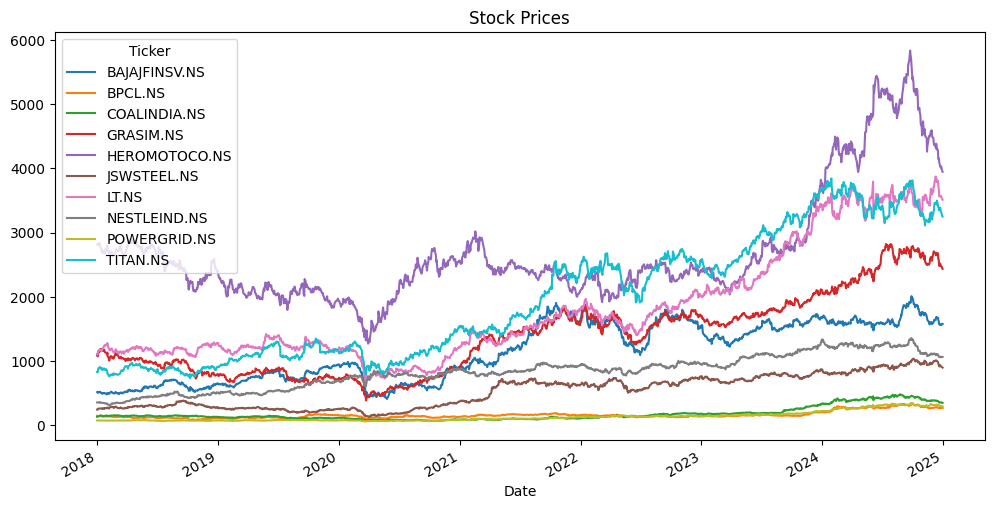

In [4]:
data.plot(figsize=(12,6))
plt.title("Stock Prices")
plt.show()

returns calculation

(approaching towards stationarity)

In [5]:
returns = data.pct_change().dropna()

In [6]:
print(returns.head())

Ticker      BAJAJFINSV.NS   BPCL.NS  COALINDIA.NS  GRASIM.NS  HEROMOTOCO.NS  \
Date                                                                          
2018-01-02      -0.013680 -0.017303      0.012751  -0.003846      -0.001401   
2018-01-03      -0.000324 -0.009804      0.006666  -0.010838       0.003032   
2018-01-04      -0.007236 -0.006870      0.021887   0.038237      -0.004341   
2018-01-05       0.012770 -0.007732      0.003420   0.037512       0.001538   
2018-01-08       0.018343  0.019479      0.031211  -0.009224       0.011243   

Ticker      JSWSTEEL.NS     LT.NS  NESTLEIND.NS  POWERGRID.NS  TITAN.NS  
Date                                                                     
2018-01-02    -0.004703 -0.008686      0.000045      0.002747 -0.008564  
2018-01-03     0.015687  0.020444     -0.000439      0.004483  0.013193  
2018-01-04     0.031448  0.031679      0.001164     -0.006447  0.042742  
2018-01-05     0.028685 -0.000608     -0.001588      0.004492  0.018815  
20

In [7]:
print(returns.tail())

Ticker      BAJAJFINSV.NS   BPCL.NS  COALINDIA.NS  GRASIM.NS  HEROMOTOCO.NS  \
Date                                                                          
2024-12-23      -0.003982  0.000173      0.002487   0.015068      -0.015519   
2024-12-24       0.000736  0.010031      0.004048  -0.009639      -0.003160   
2024-12-26      -0.003356  0.012329      0.005462  -0.007914       0.003733   
2024-12-27       0.012826 -0.006935     -0.015779  -0.000705      -0.008667   
2024-12-30      -0.001646 -0.000852     -0.006833  -0.014837      -0.011881   

Ticker      JSWSTEEL.NS     LT.NS  NESTLEIND.NS  POWERGRID.NS  TITAN.NS  
Date                                                                     
2024-12-23     0.021475  0.002934     -0.005500     -0.001583  0.012127  
2024-12-24    -0.016221 -0.000206      0.007018     -0.016492 -0.012820  
2024-12-26    -0.008027 -0.002816     -0.007754      0.000645 -0.009050  
2024-12-27    -0.001258 -0.005896      0.007303     -0.002901 -0.004168  
20

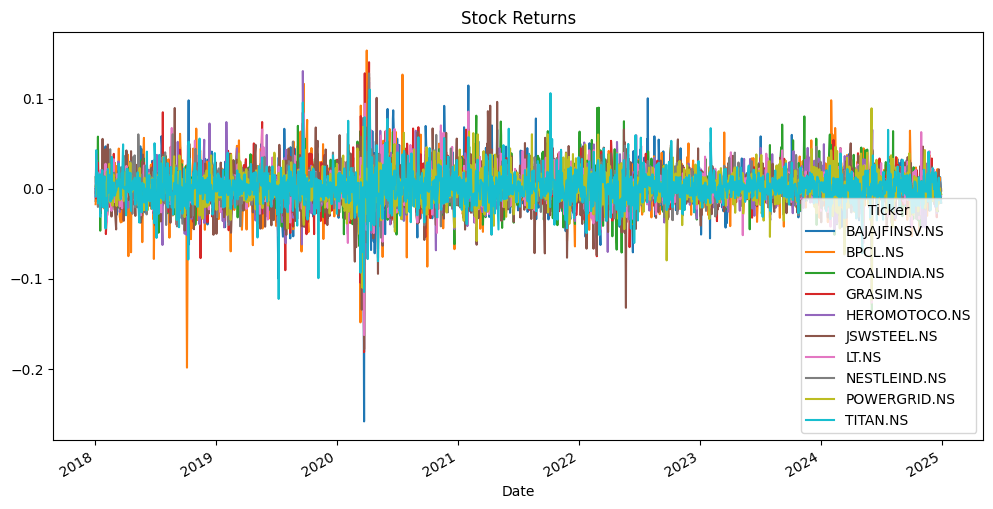

In [8]:
returns.plot(figsize=(12,6))
plt.title("Stock Returns")
plt.show()

In [9]:
print("Mean Returns:\n", returns.mean())
print("\nVolatility (Std Dev):\n", returns.std())
print("Skewness:\n", returns.skew())
print("\nKurtosis:\n", returns.kurt())

Mean Returns:
 Ticker
BAJAJFINSV.NS    0.000883
BPCL.NS          0.000614
COALINDIA.NS     0.000759
GRASIM.NS        0.000657
HEROMOTOCO.NS    0.000370
JSWSTEEL.NS      0.001006
LT.NS            0.000819
NESTLEIND.NS     0.000739
POWERGRID.NS     0.000949
TITAN.NS         0.000958
dtype: float64

Volatility (Std Dev):
 Ticker
BAJAJFINSV.NS    0.021540
BPCL.NS          0.022660
COALINDIA.NS     0.019702
GRASIM.NS        0.019443
HEROMOTOCO.NS    0.018682
JSWSTEEL.NS      0.022192
LT.NS            0.017284
NESTLEIND.NS     0.014346
POWERGRID.NS     0.016845
TITAN.NS         0.018216
dtype: float64
Skewness:
 Ticker
BAJAJFINSV.NS   -0.707529
BPCL.NS         -0.422086
COALINDIA.NS     0.104660
GRASIM.NS       -0.145061
HEROMOTOCO.NS    0.305099
JSWSTEEL.NS     -0.375462
LT.NS           -0.328958
NESTLEIND.NS     0.662178
POWERGRID.NS    -0.186612
TITAN.NS        -0.065417
dtype: float64

Kurtosis:
 Ticker
BAJAJFINSV.NS    14.964234
BPCL.NS           8.828217
COALINDIA.NS      3.241120
GRAS

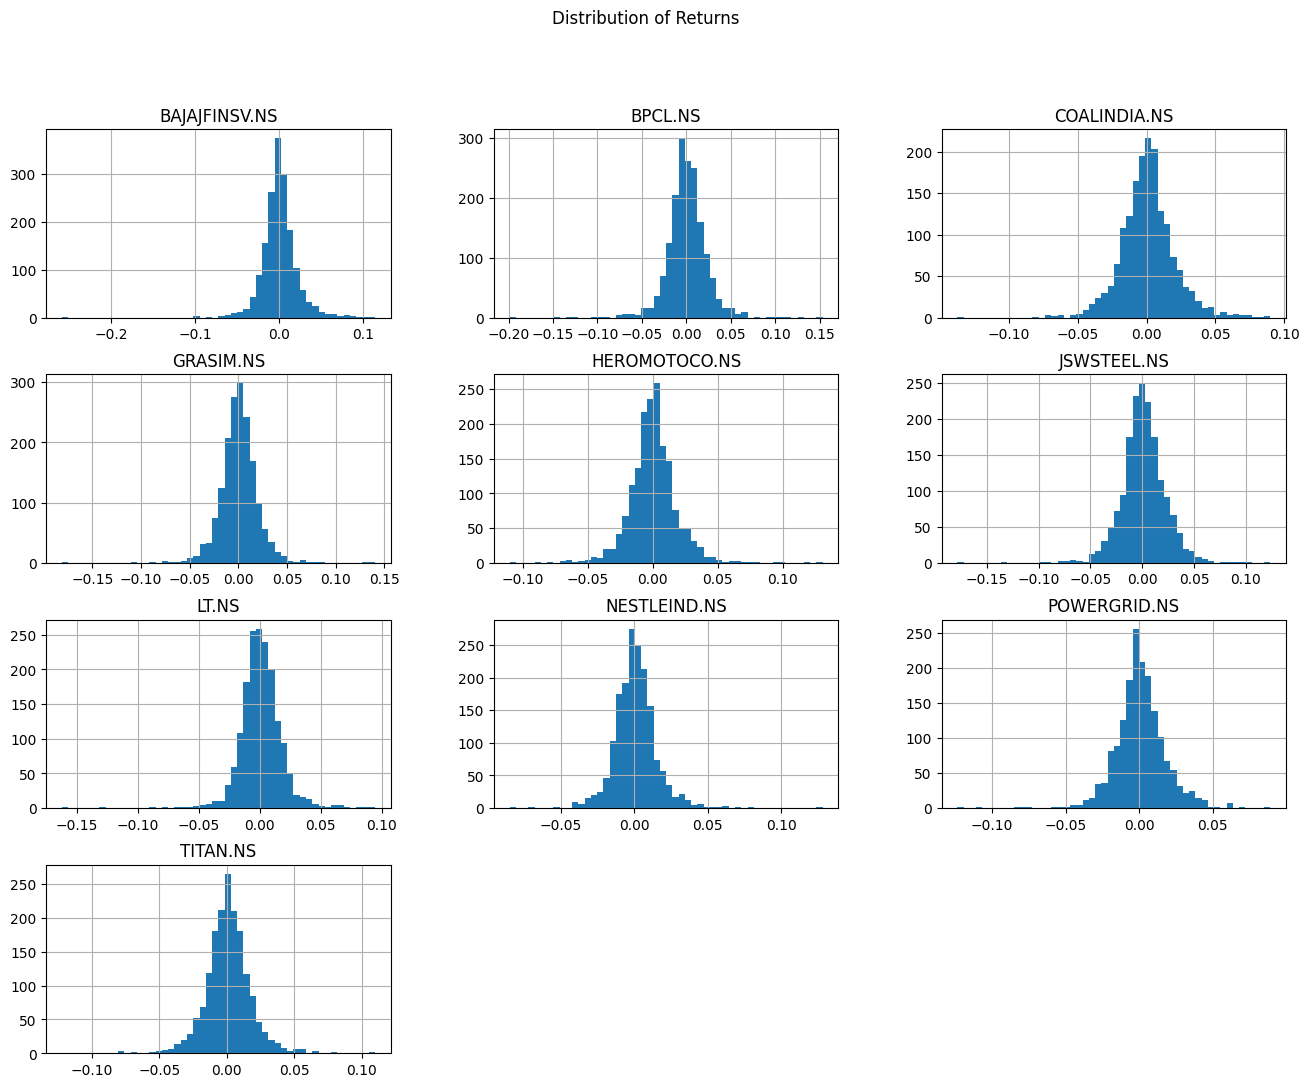

In [10]:
returns.hist(bins=50, figsize=(16,12))
plt.suptitle("Distribution of Returns")
plt.show()

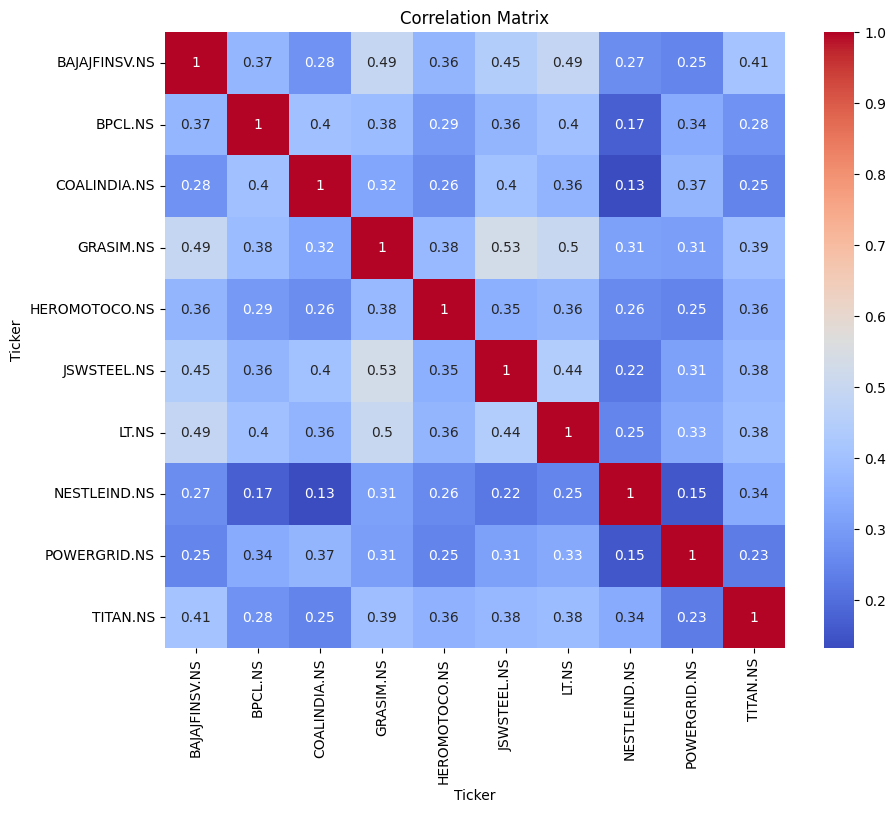

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(returns.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

The correlation matrix indicates moderate to low correlation among several stocks which suggests potential gains from diversification.

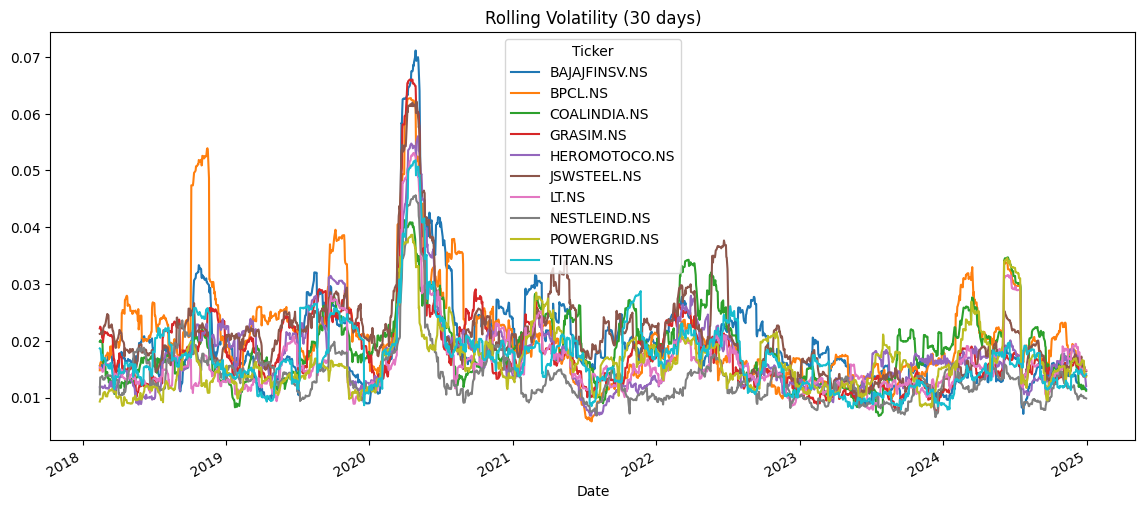

In [12]:
rolling_vol = returns.rolling(window=30).std()

rolling_vol.plot(figsize=(14,6))
plt.title("Rolling Volatility (30 days)")
plt.show()



Rolling Volatility (specifically the 30-day standard deviation used above) tracks the risk or price fluctuations of an asset over time rather than providing a single static number for the whole dataset.



feature engineering

Rt = f(Rt−1, Rt−2,..., trend, volatility)

we need to find lagged returns and other stats like trends volatality for our ML model; because ml model need trends not raw data to predict.

we will take 5 days lag i.e. we will create 5 lag variables.

Predicting today on the basis of last 5 days

> what happened in the last 5 days?

> avg return over 5 days (rolling mean)

> risk level over last 5 days (rolling volatality)

In [13]:
lags = 5

lagged_features = []

for i in range(1, lags + 1):
    lag = returns.shift(i)
    lag.columns = [col + f"_lag{i}" for col in lag.columns]
    lagged_features.append(lag)

In [14]:
# Rolling mean (trend)
rolling_mean = returns.rolling(window=5).mean()
rolling_mean.columns = [col + "_mean" for col in rolling_mean.columns]

# Rolling volatility (risk)
rolling_std = returns.rolling(window=5).std()
rolling_std.columns = [col + "_std" for col in rolling_std.columns]

In [15]:
# Combine all lag features
lags_combined = pd.concat(lagged_features, axis=1)

# Combine with rolling features
features = pd.concat([lags_combined, rolling_mean, rolling_std], axis=1)

# Target variable
target = returns.copy()

# Drop missing values
features = features.dropna()
target = target.loc[features.index]

> for each stock --- 5 lag features + 1 rolling mean + 1 rolling std = 7 features ; total features : 10*7 = 70

> for target, 10 stock will have total 10 return per day

In [16]:
print("Features shape:", features.shape)
print("Target shape:", target.shape)

print(features.head())

Features shape: (1720, 70)
Target shape: (1720, 10)
            BAJAJFINSV.NS_lag1  BPCL.NS_lag1  COALINDIA.NS_lag1  \
Date                                                              
2018-01-09            0.018343      0.019479           0.031211   
2018-01-10           -0.012420     -0.002212           0.057749   
2018-01-11            0.008368     -0.003628           0.013978   
2018-01-12           -0.010222     -0.003844          -0.000648   
2018-01-15           -0.017313     -0.005077           0.002921   

            GRASIM.NS_lag1  HEROMOTOCO.NS_lag1  JSWSTEEL.NS_lag1  LT.NS_lag1  \
Date                                                                           
2018-01-09       -0.009224            0.011243          0.003156    0.017758   
2018-01-10        0.028678           -0.009850         -0.006993   -0.004110   
2018-01-11       -0.001616           -0.003347         -0.004226   -0.006753   
2018-01-12        0.006880           -0.008363         -0.000884   -0.000151  

ML models are used to learn relationships between past returns and future returns. These models do not directly forecast long-term future values but provide estimates of expected returns, which are then used in simulation and portfolio optimization.

**Model**

In [17]:
# ML → predicts returns (μ)
#      ↓
# Monte Carlo → simulate returns
#      ↓
# Estimate μ & Σ from simulation
#      ↓
# Monte Carlo again → simulate portfolios
#      ↓
# Find optimal portfolio

train test split

In [18]:
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, shuffle=False)
print(X_train.shape, X_test.shape)

(1376, 70) (344, 70)


Random Forest Regressor

In [19]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

In [20]:
rf_mse = mean_squared_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MSE:", rf_mse)
print("Random Forest R2:", rf_r2)


Random Forest MSE: 0.00022530838242846462
Random Forest R2: 0.14179707215626805


Gradient Boosting Regressor

(this model cannot handle multi outputs, thus we need from sklearn.multioutput import MultiOutputRegressor)

In [21]:
gb_model = MultiOutputRegressor(
    GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
)

gb_model.fit(X_train, y_train)

# Predictions
gb_pred = gb_model.predict(X_test)

In [22]:
gb_mse = mean_squared_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("Gradient Boosting MSE:", gb_mse)
print("Gradient Boosting R2:", gb_r2)

Gradient Boosting MSE: 0.00012347673917046943
Gradient Boosting R2: 0.5466772658924043


In [23]:
if gb_mse < rf_mse:
    best_model = gb_model
    best_pred = gb_pred
    print("Use Gradient Boosting")
else:
    best_model = rf_model
    best_pred = rf_pred
    print("Use Random Forest")

Use Gradient Boosting


Train data → train model  
Test data → generate predictions (μ)  
Monte Carlo → simulate future using μ  
Portfolio → optimize decisions

In [24]:
gb_pred = gb_model.predict(X_test)

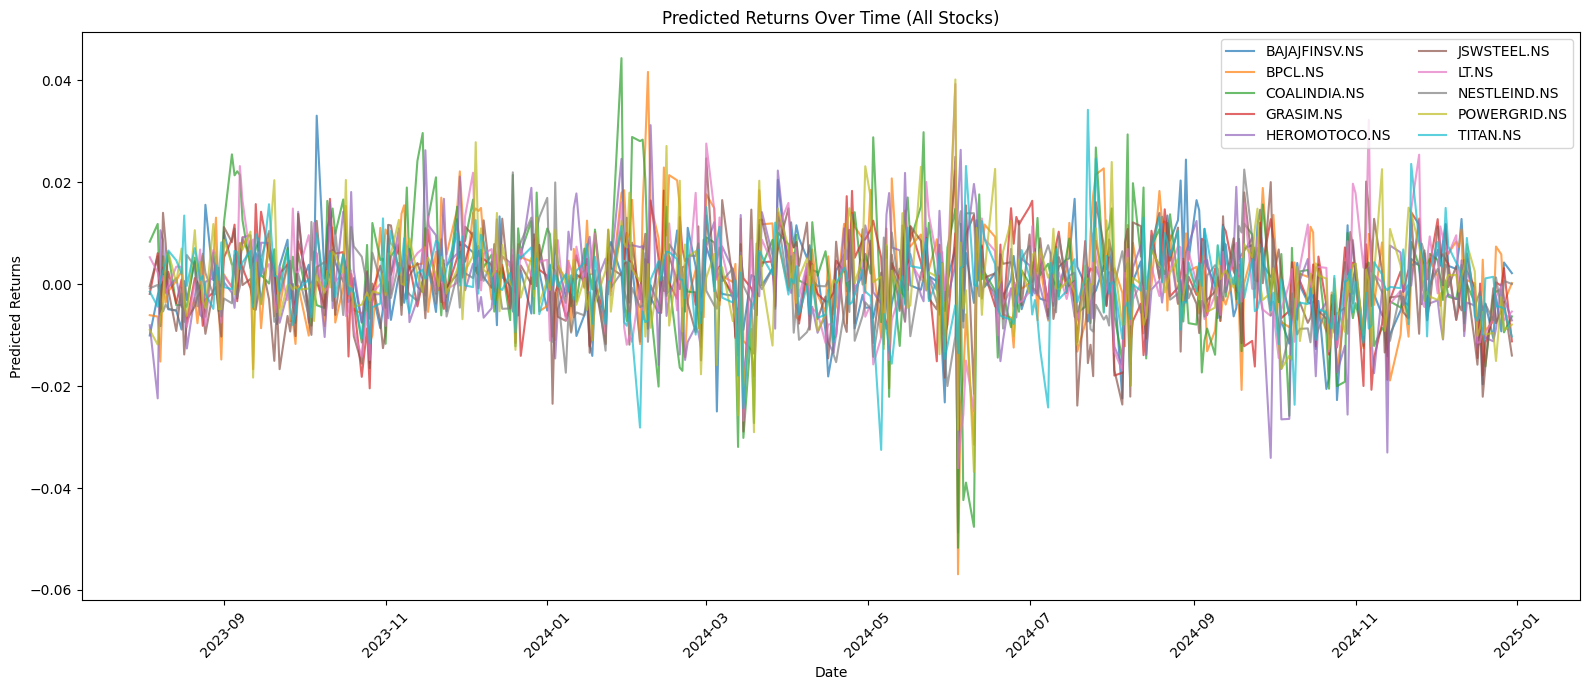

In [25]:
plt.figure(figsize=(16,7))

dates = y_test.index  # actual dates

for i in range(len(y_test.columns)):
    plt.plot(dates, best_pred[:, i], label=y_test.columns[i], alpha=0.7)

plt.title("Predicted Returns Over Time (All Stocks)")
plt.xlabel("Date")
plt.ylabel("Predicted Returns")

plt.legend(loc='upper right', ncol=2)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

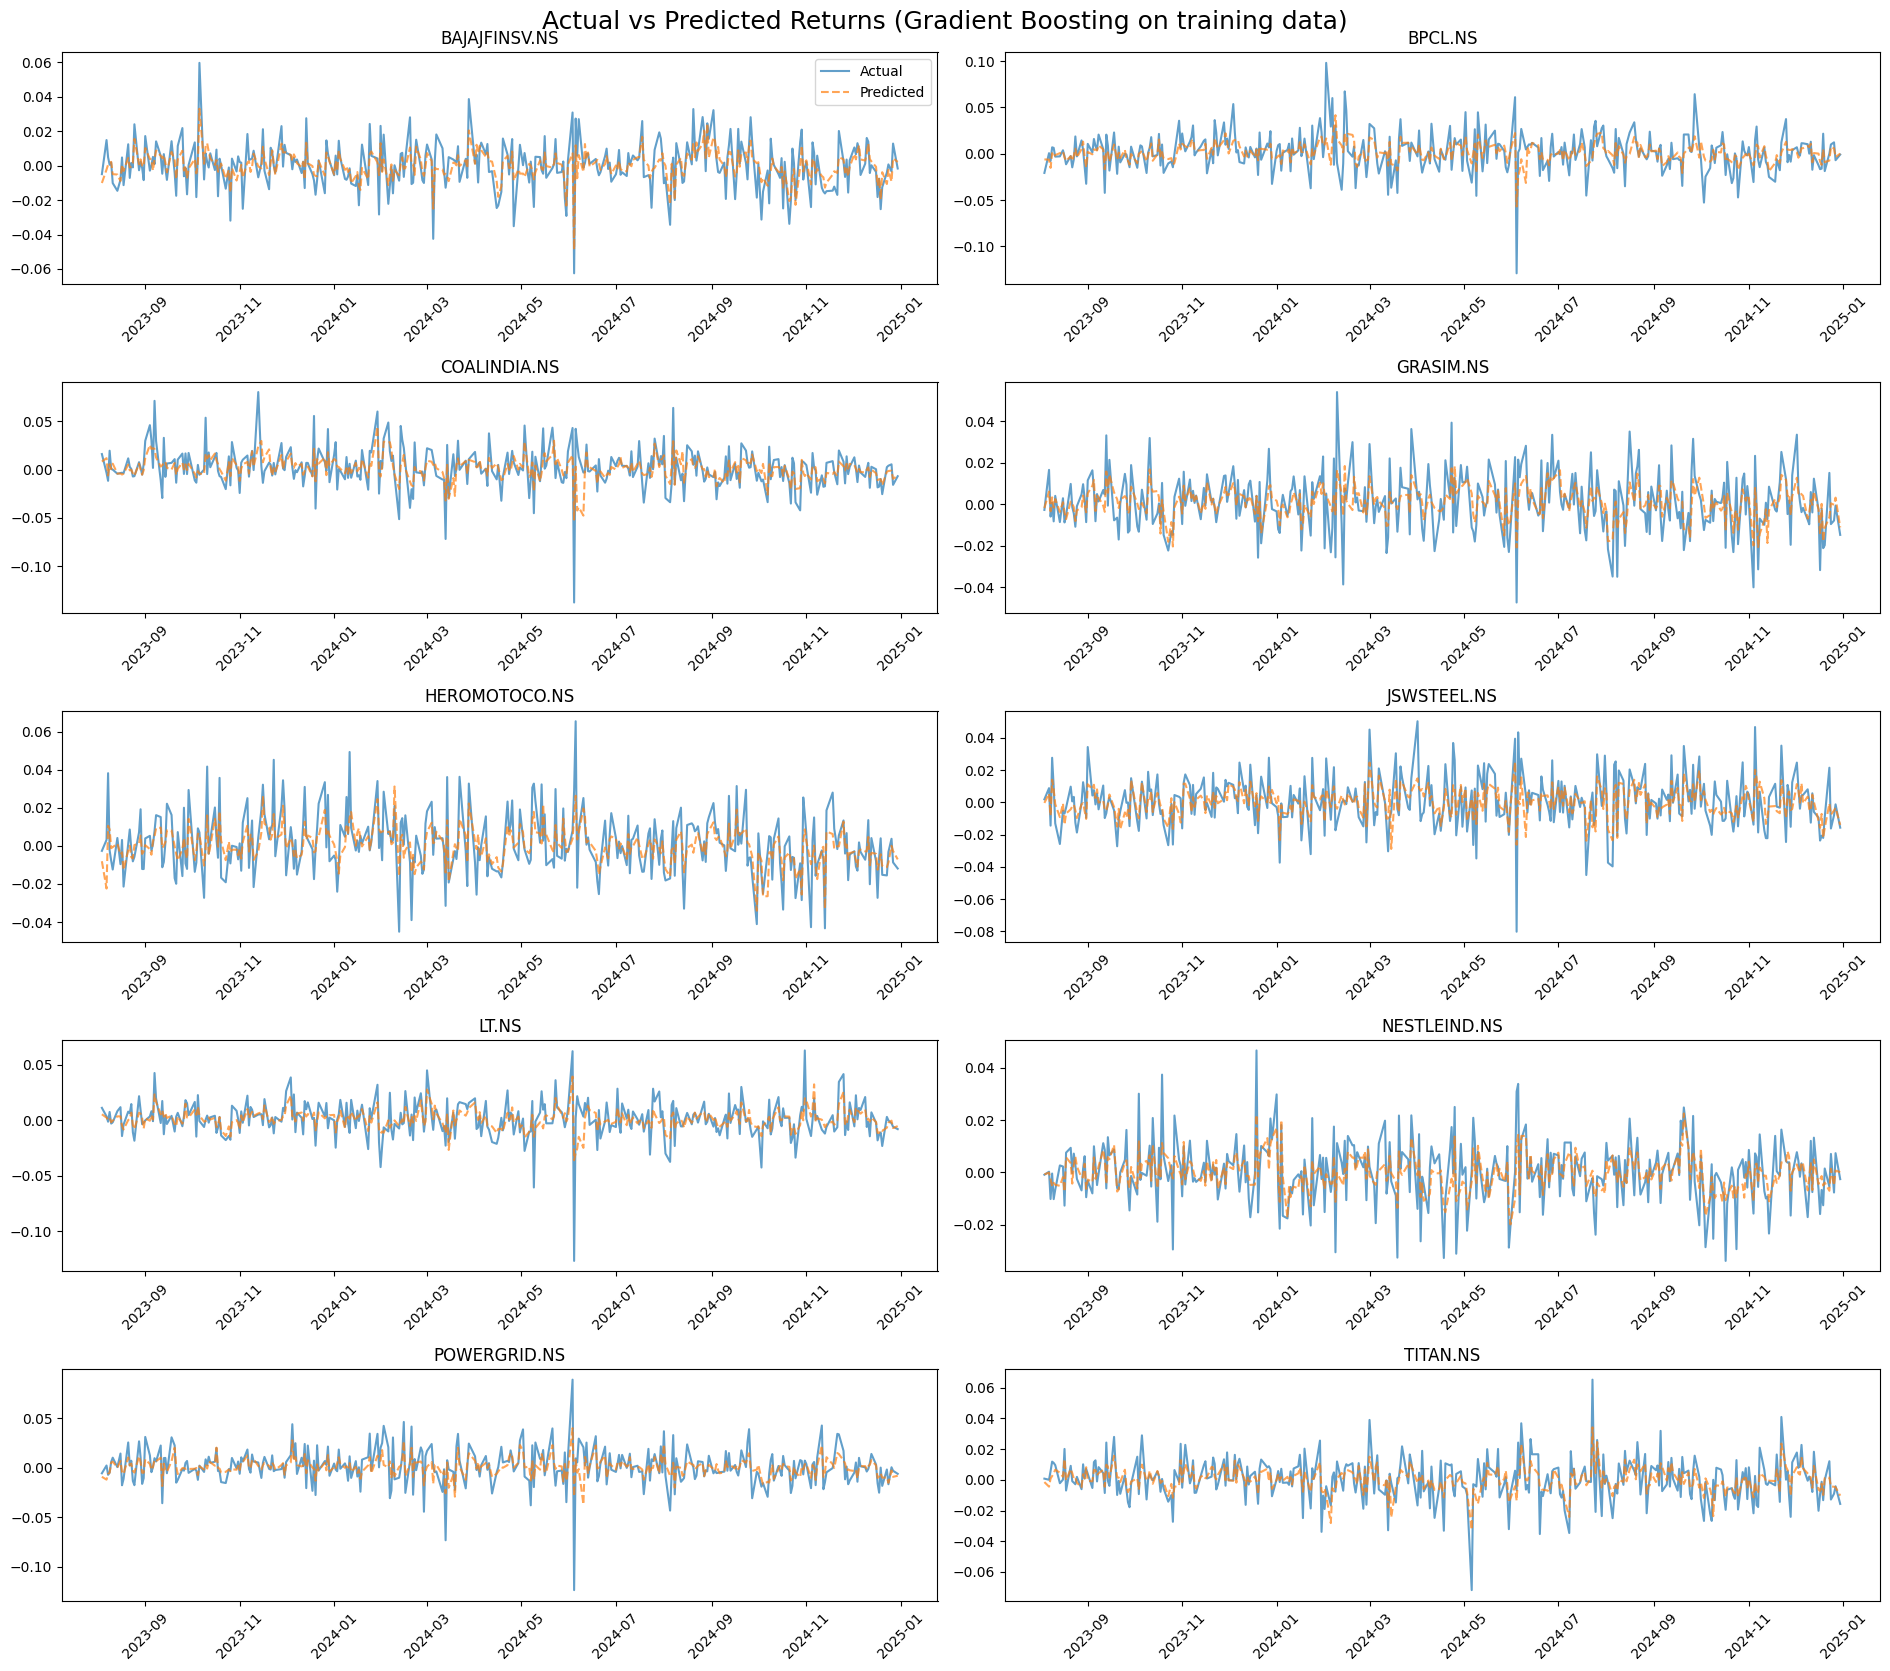

In [26]:
plt.figure(figsize=(19,17))

dates = y_test.index

for i in range(len(y_test.columns)):
    plt.subplot(5, 2, i+1)

    plt.plot(dates, y_test.iloc[:, i], label='Actual', alpha=0.7)
    plt.plot(dates, best_pred[:, i], label='Predicted', linestyle='--', alpha=0.7)

    plt.title(y_test.columns[i])
    plt.xticks(rotation=45)

    if i == 0:
        plt.legend()

plt.suptitle("Actual vs Predicted Returns (Gradient Boosting on training data)", fontsize=18)
plt.tight_layout()
plt.show()

we can do forecasting from but for this gradient boosting is not ideal

taking mean returns ans sigma using GB

In [27]:
mu = pd.DataFrame(best_pred, index=y_test.index, columns=y_test.columns)
sigma = returns.std()

In [28]:
num_simulations = 1000   # here we will do monte caerlo simulation with loop
num_days = 252
num_assets = len(stocks)

simulated_returns = np.zeros((num_simulations, num_days, num_assets))

mu_vector = mu.mean().values        # expected return
sigma_vector = sigma.values         # volatility

for i in range(num_simulations):
    for t in range(num_days):
        random_shock = np.random.normal(0, 1, num_assets)

        simulated_returns[i, t] = mu_vector + sigma_vector * random_shock

In [29]:
print(simulated_returns.shape)

(1000, 252, 10)


**portfolio optimization**

In [30]:
mean_returns = simulated_returns.mean(axis=(0,1))
print(mean_returns)

[ 0.00018717  0.00134811  0.00119251  0.00090274  0.00021744 -0.00014658
  0.00073252 -0.00039762  0.0007816   0.00013387]


In [31]:
# covariance matrix (Σ)
reshaped_returns = simulated_returns.reshape(-1, len(stocks))
cov_matrix = np.cov(reshaped_returns.T)

In [32]:
num_portfolios = 5000
num_assets = len(stocks)

results = np.zeros((num_portfolios, 3))  # return, risk, sharpe
weights_list = []

In [33]:
# 2nd monte carlo simulation with loop
for i in range(num_portfolios):

    # Generate random weights with MC simulation
    weights = np.random.random(num_assets)   # here is the mc
    weights /= np.sum(weights)

    # Expected portfolio return
    portfolio_return = np.dot(weights, mean_returns)

    # Portfolio risk
    portfolio_std = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))

    # Sharpe ratio
    sharpe = portfolio_return / portfolio_std

    # Store results
    results[i] = [portfolio_return, portfolio_std, sharpe]
    weights_list.append(weights)

In [34]:
# finding optimal portfolio

max_sharpe_idx = np.argmax(results[:,2])

optimal_weights = weights_list[max_sharpe_idx]    # giving highest sharpe index
optimal_return = results[max_sharpe_idx, 0]
optimal_risk = results[max_sharpe_idx, 1]

In [35]:
print("Optimal Weights:\n", optimal_weights)
print("\nExpected Return:", optimal_return)
print("Risk (Std Dev):", optimal_risk)

Optimal Weights:
 [0.0070635  0.1822097  0.1638258  0.1810473  0.0535898  0.02707199
 0.17171945 0.02374261 0.14423136 0.04549848]

Expected Return: 0.000848617446313516
Risk (Std Dev): 0.0075282322897657775


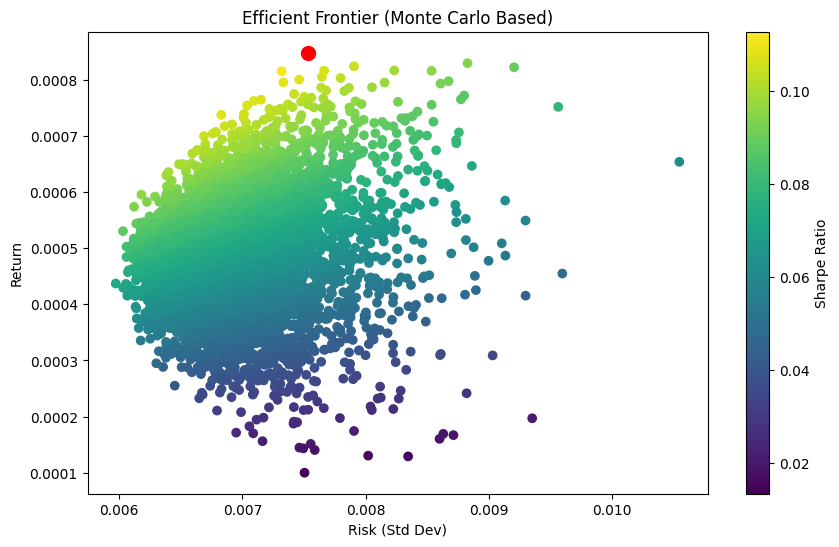

In [36]:
plt.figure(figsize=(10,6))

scatter = plt.scatter(results[:,1], results[:,0], c=results[:,2], cmap='viridis')
plt.colorbar(scatter, label='Sharpe Ratio')

# Highlight optimal portfolio
plt.scatter(optimal_risk, optimal_return, color='red', s=100)

plt.xlabel("Risk (Std Dev)")
plt.ylabel("Return")
plt.title("Efficient Frontier (Monte Carlo Based)")
plt.show()

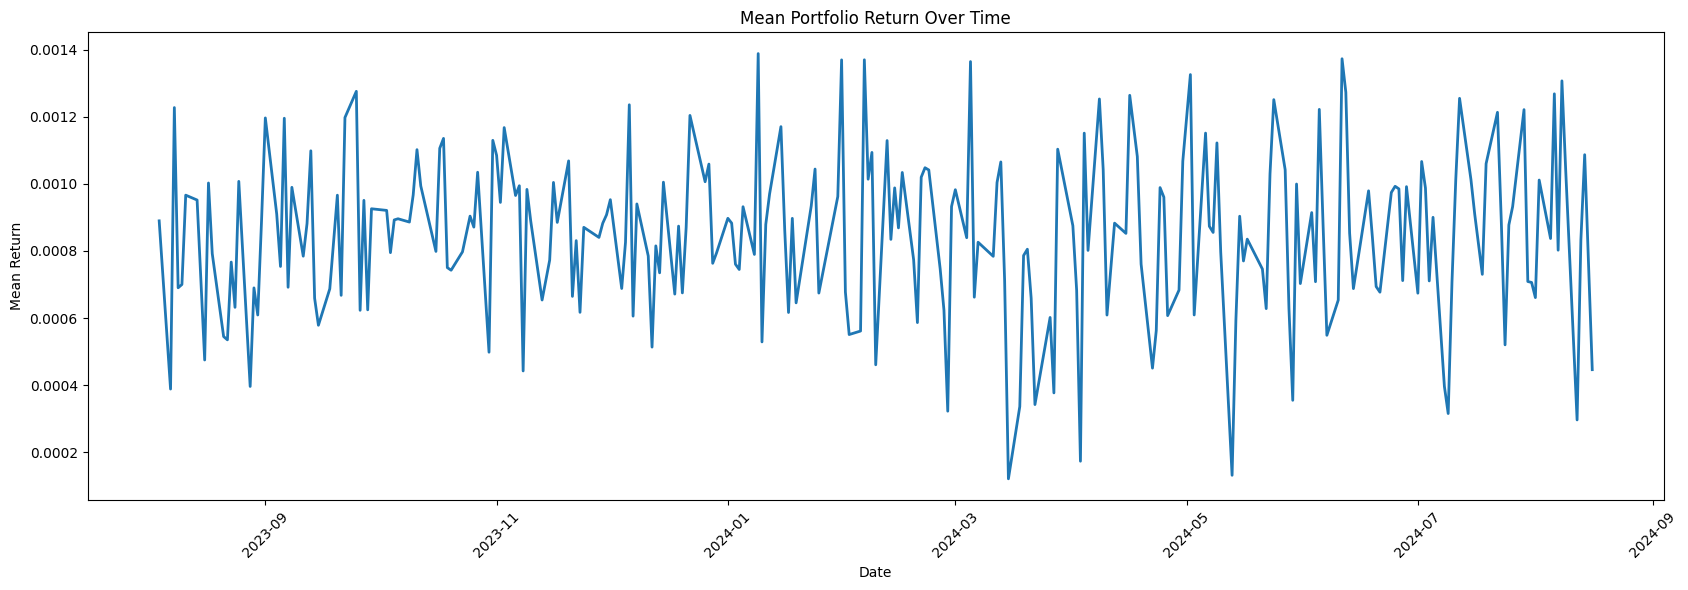

In [37]:
# use test period dates
dates = y_test.index[:252] # taking date and returns as same dimension
num_days = len(y_test)
portfolio_sim_returns = np.sum(simulated_returns * optimal_weights, axis=2) # 2 means stocks
mean_portfolio_returns = portfolio_sim_returns.mean(axis=0)                 # 0 means simulation
                                                                            # 1 means time
plt.figure(figsize=(17,6))

plt.plot(dates, mean_portfolio_returns, linewidth=2)

plt.title("Mean Portfolio Return Over Time")
plt.xlabel("Date")
plt.ylabel("Mean Return")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

risk analysis

In [38]:
# portfolio returns from simulation using optimal  weights

# Portfolio returns for each simulation and day
portfolio_sim_returns = np.dot(simulated_returns, optimal_weights)

In [39]:
portfolio_sim_returns.shape

(1000, 252)

In [40]:
portfolio_returns_flat = portfolio_sim_returns.flatten()
# flattening returns
# doing this because risk measures need a distribution
# but we have time series inside simulation
# basically combining
# all simulations + all days --→ one big sample of returns
# so we get all possible returns iun 1 dataset

In [41]:
portfolio_sim_returns.shape

(1000, 252)

In [42]:
portfolio_returns_flat.shape

(252000,)

In [43]:
# basic risk.....

portfolio_volatility = np.std(portfolio_returns_flat)

print("Portfolio Volatility:", portfolio_volatility)

Portfolio Volatility: 0.007528217352782129


In [44]:
# VaR value at risk---->

VaR_95 = np.percentile(portfolio_returns_flat, 5)

print("Value at Risk (95%):", VaR_95)

Value at Risk (95%): -0.01150415507319738


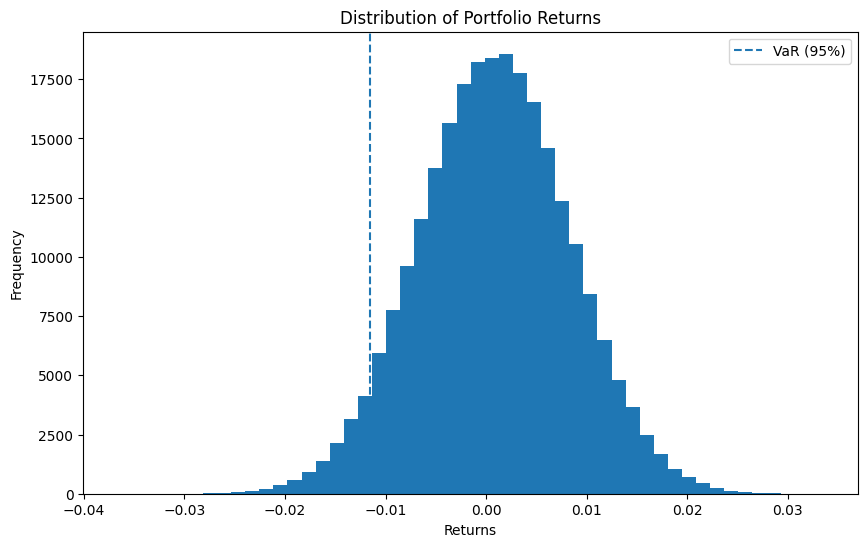

In [45]:
plt.figure(figsize=(10,6))
plt.hist(portfolio_returns_flat, bins=50)

plt.axvline(VaR_95, linestyle='--', label='VaR (95%)')

plt.title("Distribution of Portfolio Returns")
plt.xlabel("Returns")
plt.ylabel("Frequency")
plt.legend()

plt.show()

There is a 5% probability that the portfolio will lose more than ____%.

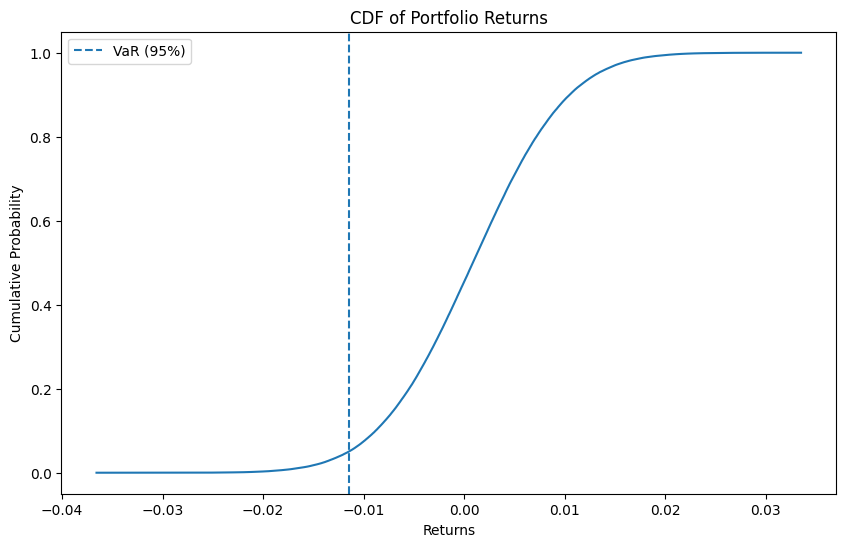

In [46]:
sorted_returns = np.sort(portfolio_returns_flat)
cdf = np.arange(len(sorted_returns)) / len(sorted_returns)

plt.figure(figsize=(10,6))
plt.plot(sorted_returns, cdf)

plt.axvline(VaR_95, linestyle='--', label='VaR (95%)')

plt.xlabel("Returns")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Portfolio Returns")
plt.legend()
plt.show()